## Setup & Import

In [6]:
import json
import sys
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd

ROOT = Path(os.getcwd())
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Root project : {ROOT}")
print(f"Python path  : OK")

Root project : d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep
Python path  : OK


## Definisi Path

In [2]:
COCO_JSON  = ROOT / "data/vision/raw/dronewaste_v1.0.json"
IMAGES_DIR = ROOT / "data/vision/raw/images"
OUTPUT_DIR = ROOT / "data/vision/processed"

print(f"COCO JSON  : {'DITEMUKAN' if COCO_JSON.exists()  else 'TIDAK DITEMUKAN'} {COCO_JSON}")
print(f"Images dir : {'DITEMUKAN' if IMAGES_DIR.exists() else 'TIDAK DITEMUKAN'} {IMAGES_DIR}")

COCO JSON  : DITEMUKAN d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\raw\dronewaste_v1.0.json
Images dir : DITEMUKAN d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\raw\images


## Load & Verifikasi COCO JSON

In [3]:
with open(COCO_JSON) as f:
    coco = json.load(f)

print("=" * 50)
print("\t\tStruktur COCO JSON")
print("=" * 50)
print(f"  Jumlah gambar    : {len(coco['images'])}")
print(f"  Jumlah anotasi   : {len(coco['annotations'])}")
print(f"  Jumlah kategori  : {len(coco['categories'])}")
print()

avg_ann = len(coco['annotations']) / len(coco['images'])
print(f"  Rata-rata anotasi/gambar : {avg_ann:.2f}")

ann_img_ids = set(a['image_id'] for a in coco['annotations'])
all_img_ids = set(i['id'] for i in coco['images'])
no_ann = len(all_img_ids - ann_img_ids)
print(f"  Gambar tanpa anotasi     : {no_ann} ({no_ann/len(coco['images'])*100:.1f}%)")
print(f"  Gambar dengan anotasi    : {len(ann_img_ids)} ({len(ann_img_ids)/len(coco['images'])*100:.1f}%)")

		Struktur COCO JSON
  Jumlah gambar    : 4993
  Jumlah anotasi   : 5135
  Jumlah kategori  : 20

  Rata-rata anotasi/gambar : 1.03
  Gambar tanpa anotasi     : 3822 (76.5%)
  Gambar dengan anotasi    : 1171 (23.5%)


## Daftar Kategori Asli

In [4]:
print("=" * 50)
print("\tKategori Asli DroneWaste")
print("=" * 50)

cat_counts = defaultdict(int)
for ann in coco['annotations']:
    cat_counts[ann['category_id']] += 1

for cat in sorted(coco['categories'], key=lambda x: x['id']):
    count = cat_counts.get(cat['id'], 0)
    bar   = '█' * (count // 10)
    print(f"  [{cat['id']:3d}] {cat['name']:<30} : {count:>5} instance  {bar}")

	Kategori Asli DroneWaste
  [  1] Rubble                         :   161 instance  ████████████████
  [  2] Construction and demolition materials :   397 instance  ███████████████████████████████████████
  [  3] Asphalt milling                :     1 instance  
  [  4] Excavation materials           :   102 instance  ██████████
  [  5] Appliances                     :    35 instance  ███
  [  6] Electronic equipment           :    11 instance  █
  [  7] Furniture                      :   189 instance  ██████████████████
  [  8] Metal barrels                  :   172 instance  █████████████████
  [  9] Plastic packaging              :   342 instance  ██████████████████████████████████
  [ 10] Wood                           :   175 instance  █████████████████
  [ 11] Pallets                        :  1016 instance  █████████████████████████████████████████████████████████████████████████████████████████████████████
  [ 12] Scrap                          :   394 instance  ████████████████

## Distribusi Superkategori (setelah class merging)

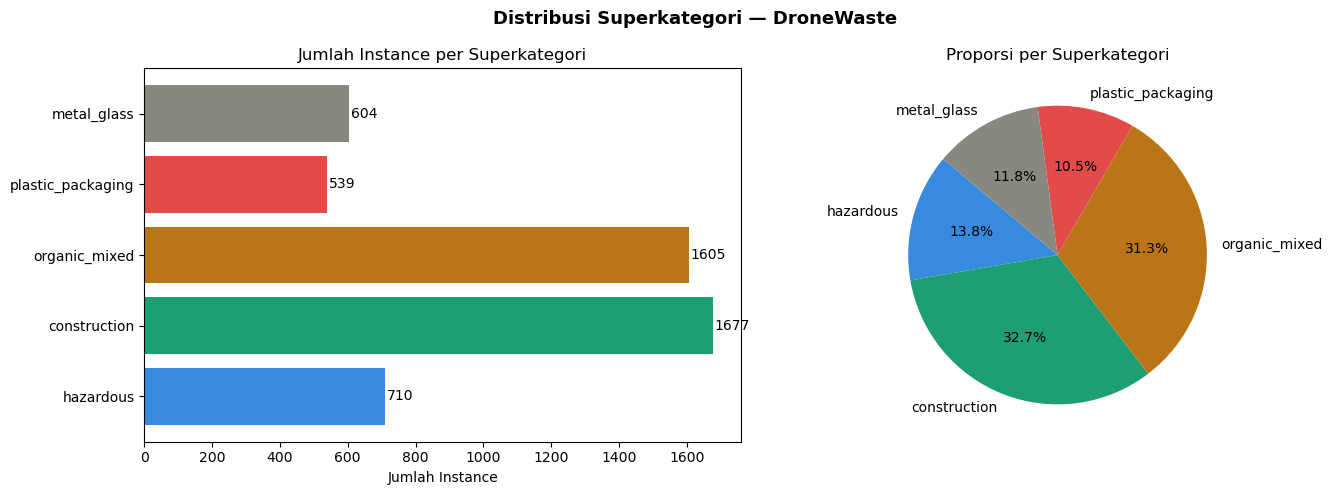


Catatan: Ketidakseimbangan kelas ini akan ditangani dengan:
  - Transfer learning dari pretrained YOLOv8x
  - Mosaic augmentation
  - Monitoring mAP per kelas (bukan hanya mAP keseluruhan)


In [11]:
from src.aerosweep.neuro.dataset import (
    DroneWasteDataset,
    SUPERCLASS_MAP,
    SUPERCLASS_NAMES,
)

cat_name_to_id = {c['name'].lower().strip(): c['id'] for c in coco['categories']}
cat_id_to_super = {}
for cat in coco['categories']:
    key = cat['name'].lower().strip()
    if key in SUPERCLASS_MAP:
        cat_id_to_super[cat['id']] = SUPERCLASS_MAP[key]
    else:
        cat_id_to_super[cat['id']] = (4, "organic_mixed")

# Hitung distribusi superkategori
super_counts = defaultdict(int)
for ann in coco['annotations']:
    sc_id, sc_name = cat_id_to_super[ann['category_id']]
    super_counts[sc_name] += 1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Superkategori — DroneWaste", fontsize=13, fontweight='bold')

names  = list(super_counts.keys())
values = list(super_counts.values())
colors = ['#378ADD', '#1D9E75', '#BA7517', '#E24B4A', '#888780']

# Bar chart
axes[0].barh(names, values, color=colors)
axes[0].set_xlabel("Jumlah Instance")
axes[0].set_title("Jumlah Instance per Superkategori")
for i, v in enumerate(values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Pie chart
axes[1].pie(values, labels=names, colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Proporsi per Superkategori")

plt.tight_layout()

output_dir = "../outputs/figures"

os.makedirs(output_dir, exist_ok=True)

plt.savefig(f"{output_dir}/distribusi_superkategori.png", dpi=150, bbox_inches='tight')

plt.show()

print("\nCatatan: Ketidakseimbangan kelas ini akan ditangani dengan:")
print("  - Transfer learning dari pretrained YOLOv8x")
print("  - Mosaic augmentation")
print("  - Monitoring mAP per kelas (bukan hanya mAP keseluruhan)")

## Visualisasi Sampel Gambar + Bounding Box

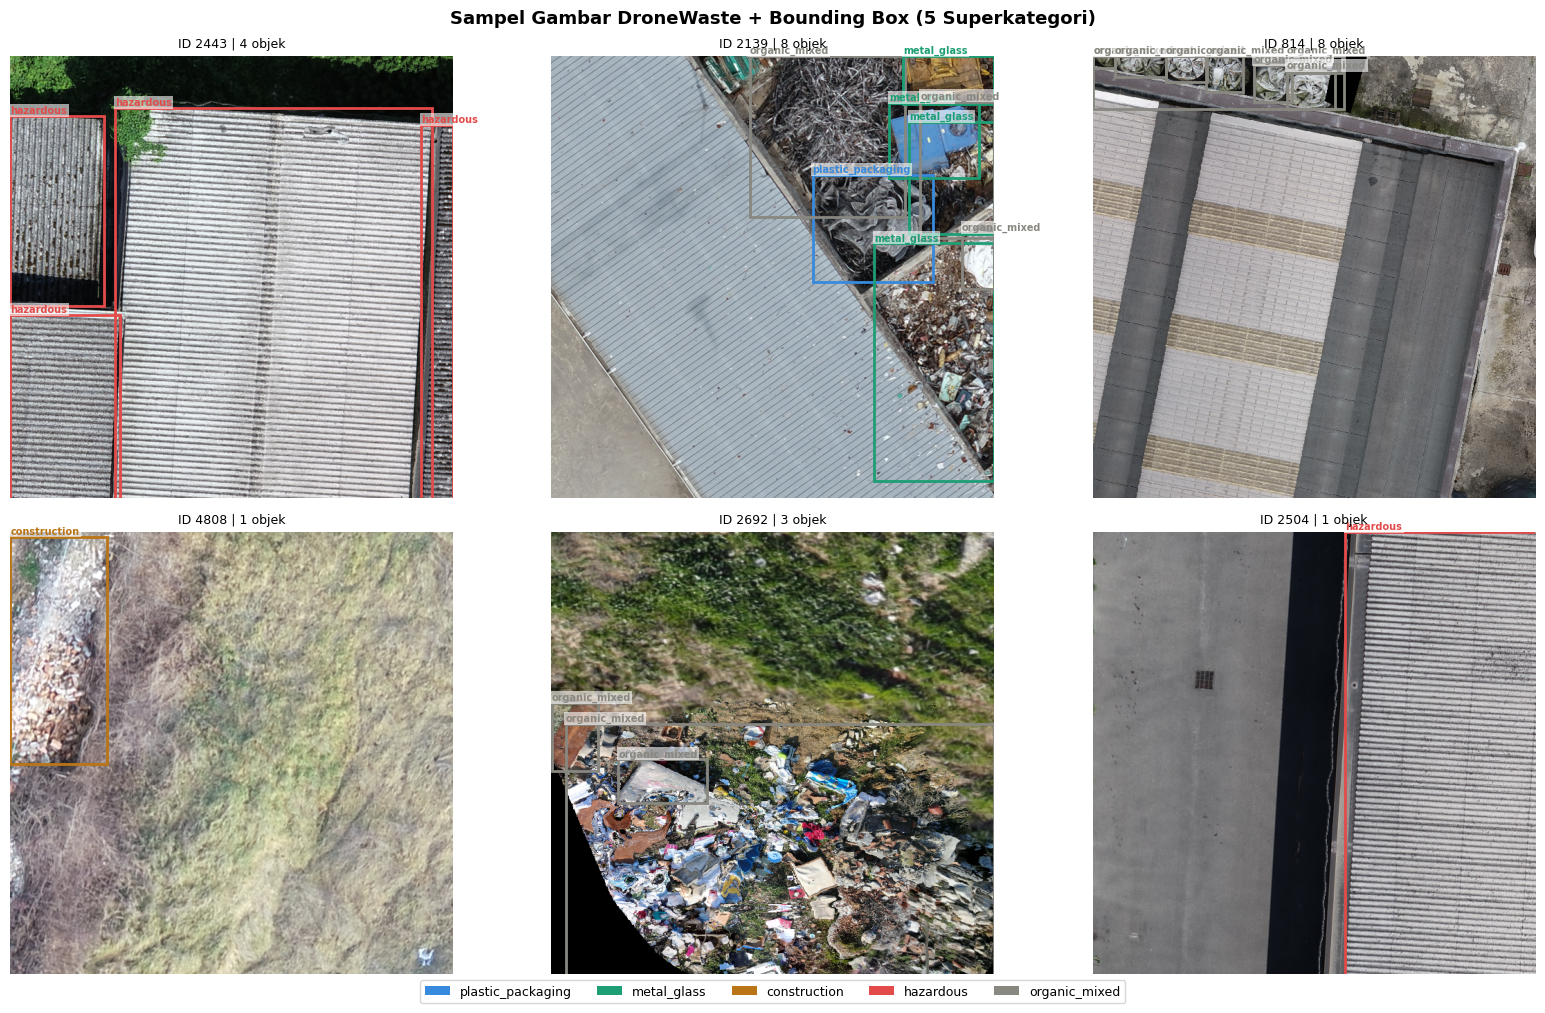

In [12]:
random.seed(42)

# Ambil 6 gambar yang punya anotasi
ann_image_ids = list(ann_img_ids)
sample_ids    = random.sample(ann_image_ids, min(6, len(ann_image_ids)))

# Build index: image_id → list anotasi
ann_by_img = defaultdict(list)
for ann in coco['annotations']:
    ann_by_img[ann['image_id']].append(ann)

# Build index: image_id → info
img_info = {img['id']: img for img in coco['images']}

# Warna per superkategori
SC_COLORS = {
    0: '#378ADD',  # plastic_packaging  — biru
    1: '#1D9E75',  # metal_glass        — hijau
    2: '#BA7517',  # construction       — amber
    3: '#E24B4A',  # hazardous          — merah
    4: '#888780',  # organic_mixed      — abu
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Sampel Gambar DroneWaste + Bounding Box (5 Superkategori)",
             fontsize=13, fontweight='bold')

for ax, img_id in zip(axes.flat, sample_ids):
    info     = img_info[img_id]
    img_path = IMAGES_DIR / info['file_name']

    try:
        img = Image.open(img_path).convert("RGB")
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"File tidak ditemukan:\n{info['file_name']}",
                ha='center', va='center', transform=ax.transAxes, color='red')
        continue

    ax.imshow(img)

    for ann in ann_by_img[img_id]:
        sc_id, sc_name = cat_id_to_super[ann['category_id']]
        x, y, w, h     = ann['bbox']
        color          = SC_COLORS[sc_id]

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x, y - 4, sc_name, color=color,
                fontsize=7, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))

    ax.set_title(f"ID {img_id} | {len(ann_by_img[img_id])} objek", fontsize=9)
    ax.axis('off')

legend_elements = [
    patches.Patch(facecolor=SC_COLORS[i], label=SUPERCLASS_NAMES[i])
    for i in range(5)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f"{output_dir}/sampel_bounding_box.png", dpi=150, bbox_inches='tight')
plt.show()

## Analisis Ukuran Bounding Box

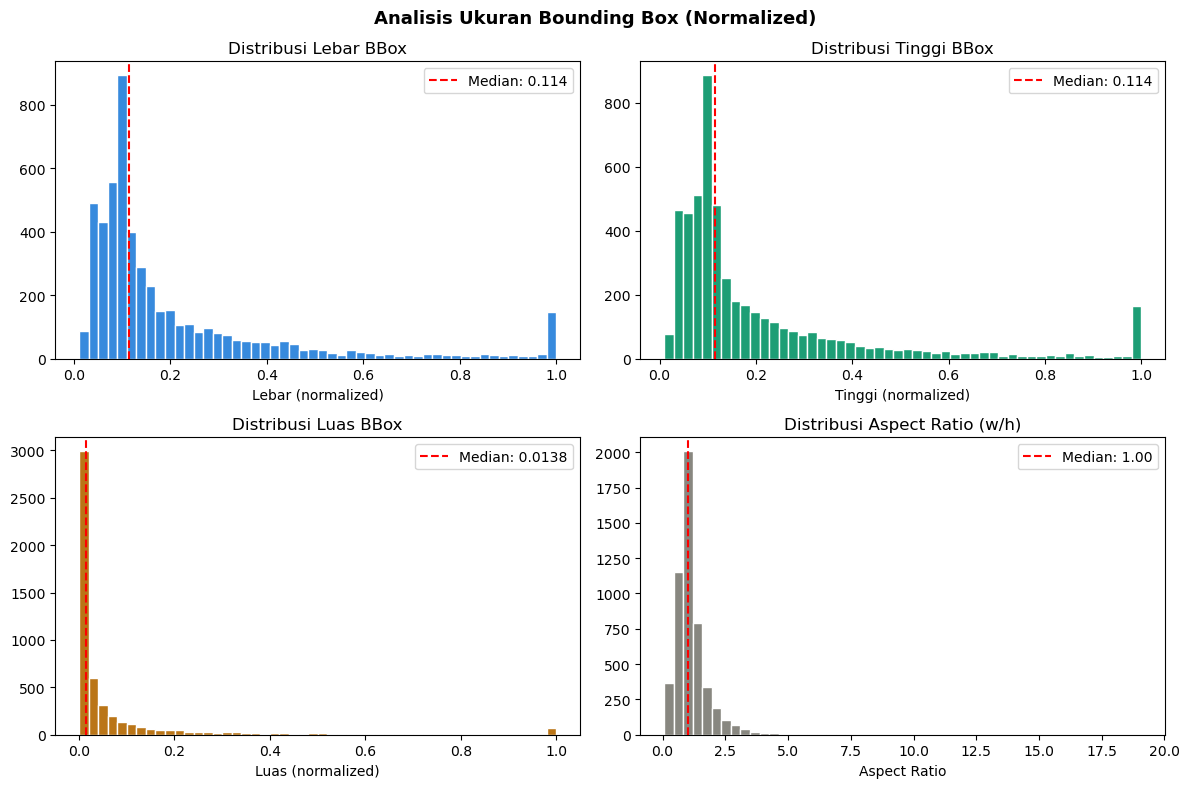


Klasifikasi ukuran objek:
  Small  (< 32²px equiv) :     6 (0.1%)
  Medium                 :  2003 (39.0%)
  Large  (> 96²px equiv) :  3126 (60.9%)

Implikasi untuk training:
  Distribusi ukuran cukup baik untuk imgsz=640


In [14]:
widths, heights, areas, aspect_ratios = [], [], [], []

for ann in coco['annotations']:
    x, y, w, h = ann['bbox']
    info       = img_info[ann['image_id']]
    W, H       = info['width'], info['height']

    # Normalisasi ke 0-1
    nw = w / W
    nh = h / H

    widths.append(nw)
    heights.append(nh)
    areas.append(nw * nh)
    if nh > 0:
        aspect_ratios.append(nw / nh)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Analisis Ukuran Bounding Box (Normalized)", fontsize=13, fontweight='bold')

axes[0,0].hist(widths,        bins=50, color='#378ADD', edgecolor='white')
axes[0,0].set_title("Distribusi Lebar BBox")
axes[0,0].set_xlabel("Lebar (normalized)")
axes[0,0].axvline(np.median(widths), color='red', linestyle='--',
                  label=f"Median: {np.median(widths):.3f}")
axes[0,0].legend()

axes[0,1].hist(heights,       bins=50, color='#1D9E75', edgecolor='white')
axes[0,1].set_title("Distribusi Tinggi BBox")
axes[0,1].set_xlabel("Tinggi (normalized)")
axes[0,1].axvline(np.median(heights), color='red', linestyle='--',
                  label=f"Median: {np.median(heights):.3f}")
axes[0,1].legend()

axes[1,0].hist(areas,         bins=50, color='#BA7517', edgecolor='white')
axes[1,0].set_title("Distribusi Luas BBox")
axes[1,0].set_xlabel("Luas (normalized)")
axes[1,0].axvline(np.median(areas), color='red', linestyle='--',
                  label=f"Median: {np.median(areas):.4f}")
axes[1,0].legend()

axes[1,1].hist(aspect_ratios, bins=50, color='#888780', edgecolor='white')
axes[1,1].set_title("Distribusi Aspect Ratio (w/h)")
axes[1,1].set_xlabel("Aspect Ratio")
axes[1,1].axvline(np.median(aspect_ratios), color='red', linestyle='--',
                  label=f"Median: {np.median(aspect_ratios):.2f}")
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/analisis_bbox.png", dpi=150, bbox_inches='tight')
plt.show()

# Klasifikasi objek berdasarkan ukuran (COCO standard)
small  = sum(1 for a in areas if a < 0.02**2)   # < 32x32 px di 1000x1000
medium = sum(1 for a in areas if 0.02**2 <= a < 0.1**2)
large  = sum(1 for a in areas if a >= 0.1**2)
total  = len(areas)

print("\nKlasifikasi ukuran objek:")
print(f"  Small  (< 32²px equiv) : {small:>5} ({small/total*100:.1f}%)")
print(f"  Medium                 : {medium:>5} ({medium/total*100:.1f}%)")
print(f"  Large  (> 96²px equiv) : {large:>5} ({large/total*100:.1f}%)")
print()
print("Implikasi untuk training:")
if small / total > 0.5:
    print("  [!]  Mayoritas objek KECIL → pertimbangkan imgsz=1280 untuk akurasi lebih baik")
else:
    print("  Distribusi ukuran cukup baik untuk imgsz=640")

## Jalankan dataset.py (Prepare Data)

In [15]:
from src.aerosweep.neuro.dataset import DroneWasteDataset

ds = DroneWasteDataset(
    coco_json  = COCO_JSON,
    images_dir = IMAGES_DIR,
    output_dir = OUTPUT_DIR,
)

# Cek distribusi sebelum prepare
print("Distribusi superkategori (ground truth):")
dist = ds.get_class_distribution()
for name, cnt in sorted(dist.items(), key=lambda x: -x[1]):
    bar = '█' * (cnt // 50)
    print(f"  {name:<25} : {cnt:>5}  {bar}")

print()

Distribusi superkategori (ground truth):
[dataset] Membaca d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\raw\dronewaste_v1.0.json ...
[dataset] 4993 gambar, 5135 anotasi dimuat.
[dataset] Category map: 20 terpetakan, 0 fallback.
  construction              :  1677  █████████████████████████████████
  organic_mixed             :  1605  ████████████████████████████████
  hazardous                 :   710  ██████████████
  metal_glass               :   604  ████████████
  plastic_packaging         :   539  ██████████



##  Jalankan Prepare (Tulis Label YOLO + Grid CSV)

In [16]:
paths = ds.prepare(
    grid_size  = (8, 8),  
    n_folds    = 5,
    fold_idx   = 0,
    copy_images= False, 
)

print("\nOutput yang dihasilkan:")
for k, v in paths.items():
    exists = "[BERHASIL]" if Path(v).exists() else "[TIDAK BERHASIL]"
    print(f"  {exists} {k:<12} : {v}")

[dataset] Membaca d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\raw\dronewaste_v1.0.json ...
[dataset] 4993 gambar, 5135 anotasi dimuat.
[dataset] Category map: 20 terpetakan, 0 fallback.
[dataset] K-Fold 1/5: train=3993, val=1000
[dataset] Label YOLO ditulis ke d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\processed
[dataset] dataset.yaml ditulis ke d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\processed\dataset.yaml
[dataset] Grid CSV ditulis ke data\tabular\grid_results.csv

  DroneWaste dataset siap
  Train : 3993 gambar
  Val   : 1000 gambar  (fold 0/5)
  YAML  : d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\processed\dataset.yaml
  Grid  : data\tabular\grid_results.csv


Output yang dihasilkan:
  [BERHASIL] yolo_dir     : d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\processed
  [BERHASIL] yaml_path    : d:\Arsip Hafizh Fadhl Muhammad\Project\aerosweep\data\vision\processed\dataset.yaml
  [BERHASIL] grid_c

## Verifikasi Label YOLO

In [17]:
labels_train = list((OUTPUT_DIR / "labels/train").glob("*.txt"))
labels_val   = list((OUTPUT_DIR / "labels/val").glob("*.txt"))

print(f"Label train : {len(labels_train)} file")
print(f"Label val   : {len(labels_val)} file")
print()

# Tampilkan isi beberapa file label
print("Contoh isi file label YOLO (5 file pertama yang tidak kosong):")
count = 0
for lbl_path in labels_train:
    content = lbl_path.read_text().strip()
    if content:
        print(f"\n  {lbl_path.name}:")
        for line in content.split('\n')[:3]:  # max 3 baris per file
            parts = line.split()
            cls   = int(parts[0])
            print(f"    kelas={cls} ({SUPERCLASS_NAMES[cls]}), "
                  f"cx={float(parts[1]):.4f}, cy={float(parts[2]):.4f}, "
                  f"w={float(parts[3]):.4f}, h={float(parts[4]):.4f}")
        count += 1
        if count >= 5:
            break

Label train : 3993 file
Label val   : 1000 file

Contoh isi file label YOLO (5 file pertama yang tidak kosong):

  site10_12.txt:
    kelas=0 (plastic_packaging), cx=0.9398, cy=0.2891, w=0.1203, h=0.1531
    kelas=0 (plastic_packaging), cx=0.9398, cy=0.2891, w=0.1203, h=0.1531

  site10_13.txt:
    kelas=0 (plastic_packaging), cx=0.1016, cy=0.2859, w=0.2031, h=0.1594
    kelas=0 (plastic_packaging), cx=0.1016, cy=0.2859, w=0.2031, h=0.1594

  site10_20.txt:
    kelas=0 (plastic_packaging), cx=0.3758, cy=0.9422, w=0.3266, h=0.1156
    kelas=4 (organic_mixed), cx=0.2297, cy=0.9680, w=0.3906, h=0.0641
    kelas=0 (plastic_packaging), cx=0.7477, cy=0.8195, w=0.0891, h=0.0359

  site10_21.txt:
    kelas=0 (plastic_packaging), cx=0.0508, cy=0.5078, w=0.0484, h=0.0500
    kelas=0 (plastic_packaging), cx=0.0898, cy=0.2547, w=0.0547, h=0.0437
    kelas=0 (plastic_packaging), cx=0.0508, cy=0.5078, w=0.0484, h=0.0500

  site10_28.txt:
    kelas=0 (plastic_packaging), cx=0.4148, cy=0.1141, w=0.404

## Verifikasi Grid CSV (Output untuk Fuzzy)

  Preview Grid CSV (Input untuk Fuzzy)
  Total baris    : 4209
  Total kolom    : 11
  Kolom          : ['image_id', 'file_name', 'grid_row', 'grid_col', 'jumlah_sampah', 'kepadatan_pct', 'count_plastic_packaging', 'count_metal_glass', 'count_construction', 'count_hazardous', 'count_organic_mixed']

 image_id     file_name  grid_row  grid_col  jumlah_sampah  kepadatan_pct  count_plastic_packaging  count_metal_glass  count_construction  count_hazardous  count_organic_mixed
       23  site3_26.png         4         4              2        24.2188                        0                  0                   0                2                    0
       23  site3_26.png         5         4              2        23.6250                        0                  0                   0                2                    0
       45  site3_56.png         6         2              2        30.6250                        0                  0                   0                2                 

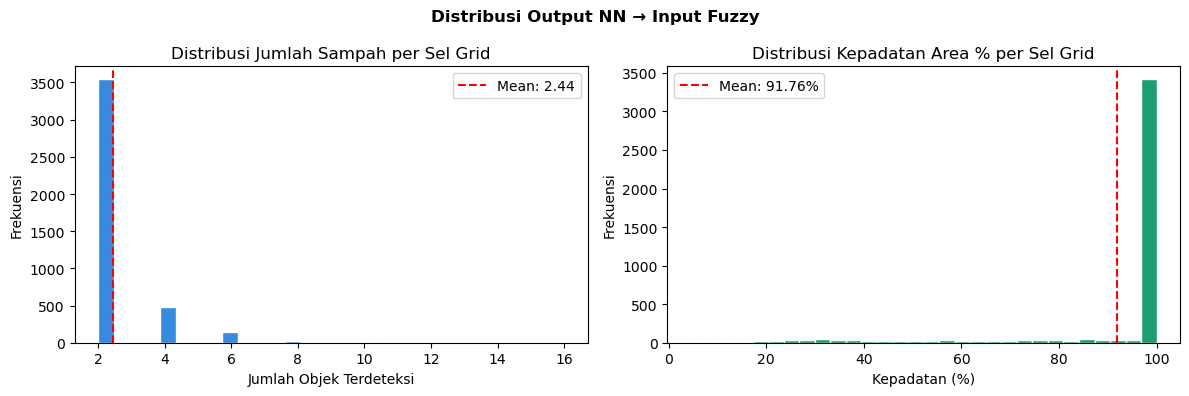

In [ ]:
grid_csv = ROOT / "data/tabular/grid_results.csv"

if not grid_csv.exists():
    print(" grid_results.csv belum ada, jalankan Cell 8 dulu")
else:
    df = pd.read_csv(grid_csv)

    print("=" * 55)
    print("  Preview Grid CSV (Input untuk Fuzzy)")
    print("=" * 55)
    print(f"  Total baris    : {len(df)}")
    print(f"  Total kolom    : {len(df.columns)}")
    print(f"  Kolom          : {list(df.columns)}")
    print()
    print(df.head(10).to_string(index=False))
    print()

    print("Statistik deskriptif kolom utama:")
    print(df[['jumlah_sampah', 'kepadatan_pct']].describe().round(4))

    # Visualisasi distribusi output NN
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Distribusi Output NN → Input Fuzzy", fontsize=12, fontweight='bold')

    axes[0].hist(df['jumlah_sampah'], bins=30, color='#378ADD', edgecolor='white')
    axes[0].set_title("Distribusi Jumlah Sampah per Sel Grid")
    axes[0].set_xlabel("Jumlah Objek Terdeteksi")
    axes[0].set_ylabel("Frekuensi")
    axes[0].axvline(df['jumlah_sampah'].mean(), color='red', linestyle='--',
                    label=f"Mean: {df['jumlah_sampah'].mean():.2f}")
    axes[0].legend()

    axes[1].hist(df['kepadatan_pct'], bins=30, color='#1D9E75', edgecolor='white')
    axes[1].set_title("Distribusi Kepadatan Area % per Sel Grid")
    axes[1].set_xlabel("Kepadatan (%)")
    axes[1].set_ylabel("Frekuensi")
    axes[1].axvline(df['kepadatan_pct'].mean(), color='red', linestyle='--',
                    label=f"Mean: {df['kepadatan_pct'].mean():.2f}%")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}/distribusi_output_nn.png", dpi=150, bbox_inches='tight')
    plt.show()

## Ringkasan & Kesimpulan EDA

In [20]:
print("=" * 60)
print("  RINGKASAN EDA — AeroSweep")
print("=" * 60)
print()
print(f"  Dataset        : DroneWaste")
print(f"  Total gambar   : {len(coco['images'])}")
print(f"  Total anotasi  : {len(coco['annotations'])}")
print(f"  Superkategori  : 5 (dari 20 kelas asli)")
print()

# Cek ukuran dominan
pct_small = small / total * 100
if pct_small > 50:
    obj_note = f"[WARNING]  {pct_small:.0f}% objek kecil → perlu perhatian extra"
else:
    obj_note = f"[BERHASIL] Distribusi ukuran wajar"

print(f"  Ukuran objek   : {obj_note}")
print()
print("  Rekomendasi training:")
print(f"    Model        : YOLOv8x (pretrained)")
print(f"    imgsz        : 640 (naikan ke 1280 kalau mAP < 30%)")
print(f"    batch        : 8 (RTX 3060 12GB)")
print(f"    epochs       : 100 dengan early stopping patience=20")
print(f"    augmentasi   : mosaic=1.0, flipud=0.5, fliplr=0.5")
print()
print("  Output untuk Fuzzy (data/tabular/grid_results.csv):")
if grid_csv.exists():
    df = pd.read_csv(grid_csv)
    print(f"    Total sel grid dengan sampah : {len(df)}")
    print(f"    Rata-rata jumlah sampah/sel  : {df['jumlah_sampah'].mean():.2f}")
    print(f"    Rata-rata kepadatan/sel      : {df['kepadatan_pct'].mean():.2f}%")
print()
print("=" * 60)

  RINGKASAN EDA — AeroSweep

  Dataset        : DroneWaste
  Total gambar   : 4993
  Total anotasi  : 5135
  Superkategori  : 5 (dari 20 kelas asli)

  Ukuran objek   : [BERHASIL] Distribusi ukuran wajar

  Rekomendasi training:
    Model        : YOLOv8x (pretrained)
    imgsz        : 640 (naikan ke 1280 kalau mAP < 30%)
    batch        : 8 (RTX 3060 12GB)
    epochs       : 100 dengan early stopping patience=20
    augmentasi   : mosaic=1.0, flipud=0.5, fliplr=0.5

  Output untuk Fuzzy (data/tabular/grid_results.csv):
    Total sel grid dengan sampah : 4209
    Rata-rata jumlah sampah/sel  : 2.44
    Rata-rata kepadatan/sel      : 91.76%

